# Documentación Metodológica: Representación Gráfica Comparativa
### Transporte Privado vs. Transporte Público

---

Este documento describe las fórmulas estadísticas y los procedimientos gráficos empleados en el análisis comparativo de trayectos origen-destino, detallando qué representa cada variable en el contexto del estudio.

---
## 1. Media Aritmética por Trayecto

Para cada par origen-destino único pueden existir múltiples mediciones a lo largo del tiempo. Con el fin de obtener un valor representativo de cada trayecto, se calcula la **media aritmética** de todas sus observaciones.

$$\bar{x}_{trayecto} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

### Valores de cada variable

| Símbolo | Descripción | Ejemplo concreto |
|---|---|---|
| $x_i$ | Cada medición individual de ese trayecto | Duración registrada en una salida concreta (minutos) |
| $n$ | Número de veces que aparece ese par origen-destino en los datos | 15 registros del trayecto A→B |
| $\bar{x}_{trayecto}$ | Duración media representativa de ese trayecto | Tiempo promedio de A→B en coche |

Esta operación se aplica de forma **independiente** para cada modo de transporte:

- **Transporte privado:** $\bar{x}_{trayecto}$ = media de `duracion_con_trafico_min` para ese par origen-destino  
- **Transporte público:** $\bar{x}_{trayecto}$ = media de `duracion_sin_trafico_min` para ese par origen-destino  
- **Distancia:** $\bar{x}_{trayecto}$ = media de `distancia_km` para ese par origen-destino (calculada por separado en cada dataset)

---
## 2. Media entre Dos Distancias

Una vez agregados ambos datasets, cada trayecto dispone de dos estimaciones de distancia: la del dataset de conducción y la del dataset de transporte público. La distancia definitiva del trayecto se calcula como la media de ambas.

$$d_{km} = \frac{d_{privado} + d_{p\acute{u}blico}}{2}$$

### Valores de cada variable

| Símbolo | Descripción |
|---|---|
| $d_{privado}$ | Distancia media del trayecto según el dataset de conducción (`distancia_drive`) |
| $d_{p\acute{u}blico}$ | Distancia media del trayecto según el dataset de transporte público (`distancia_publico`) |
| $d_{km}$ | Distancia media definitiva del trayecto, usada para ordenar y graficar |

---
## 3. Peso Ponderado por Trayecto

Dado que distintos trayectos tienen distinto número de mediciones, se asigna a cada uno un **peso** que refleja cuántas observaciones reales hay detrás de su media. Esto evita que trayectos con pocas mediciones influyan igual que trayectos con muchas.

$$w_j = \frac{n_{privado,j} + n_{p\acute{u}blico,j}}{2}$$

### Valores de cada variable

| Símbolo | Descripción |
|---|---|
| $n_{privado,j}$ | Número de registros del trayecto $j$ en el dataset de conducción (`n_drive`) |
| $n_{p\acute{u}blico,j}$ | Número de registros del trayecto $j$ en el dataset de transporte público (`n_publico`) |
| $w_j$ | Peso del trayecto $j$, proporcional al volumen de datos disponibles |

---
## 4. Medias Ponderadas Globales

Para calcular la correlación correctamente, se necesitan las medias globales de los tiempos. En lugar de dar el mismo peso a cada trayecto, se pondera cada uno por $w_j$, de modo que los trayectos con más observaciones contribuyen más a la media global.

$$\bar{X} = \frac{\displaystyle\sum_{j=1}^{N} w_j \cdot \bar{x}_j}{\displaystyle\sum_{j=1}^{N} w_j} \qquad \bar{Y} = \frac{\displaystyle\sum_{j=1}^{N} w_j \cdot \bar{y}_j}{\displaystyle\sum_{j=1}^{N} w_j}$$

### Valores de cada variable

| Símbolo | Descripción |
|---|---|
| $\bar{x}_j$ | Tiempo medio en **transporte privado** del trayecto $j$ (`tiempo_privado`) |
| $\bar{y}_j$ | Tiempo medio en **transporte público** del trayecto $j$ (`tiempo_publico`) |
| $w_j$ | Peso del trayecto $j$ (definido en la sección anterior) |
| $N$ | Número total de trayectos comparables (pares origen-destino comunes a ambos datasets) |
| $\bar{X}$ | Media global ponderada de los tiempos en transporte privado |
| $\bar{Y}$ | Media global ponderada de los tiempos en transporte público |

> **¿Por qué ponderar?** Sin ponderación, un trayecto con 2 mediciones influiría igual que uno con 200 en la media global, introduciendo sesgo.

---
## 5. Correlación de Pearson Ponderada

La correlación de Pearson mide el grado de relación lineal entre los tiempos de transporte privado y público. La versión ponderada da más importancia a los trayectos con mayor número de observaciones.

$$r = \frac{\displaystyle\sum_{j=1}^{N} w_j \cdot (\bar{x}_j - \bar{X})(\bar{y}_j - \bar{Y})}{\sqrt{\displaystyle\sum_{j=1}^{N} w_j(\bar{x}_j - \bar{X})^2 \cdot \displaystyle\sum_{j=1}^{N} w_j(\bar{y}_j - \bar{Y})^2}}$$

### Valores de cada variable

| Símbolo | Descripción |
|---|---|
| $\bar{x}_j$ | Tiempo medio en **transporte privado** del trayecto $j$ |
| $\bar{X}$ | Media global ponderada de todos los tiempos en transporte privado |
| $\bar{y}_j$ | Tiempo medio en **transporte público** del trayecto $j$ |
| $\bar{Y}$ | Media global ponderada de todos los tiempos en transporte público |
| $w_j$ | Peso del trayecto $j$ |
| $N$ | Número total de trayectos comparables |
| $r$ | Coeficiente de correlación de Pearson ponderado $\in [-1, 1]$ |

### Interpretación de $r$

| Valor de $r$ | Interpretación |
|---|---|
| $r \approx 1$ | Relación lineal positiva fuerte: a mayor tiempo en privado, mayor en público |
| $r \approx 0$ | Sin relación lineal entre ambos modos |
| $r \approx -1$ | Relación lineal negativa fuerte (infrecuente en este contexto) |

### Descomposición de la fórmula

- **Numerador:** covarianza ponderada entre tiempos privado y público. Mide si ambas variables crecen juntas.
- **Denominador:** producto de las desviaciones típicas ponderadas de cada variable. Normaliza el resultado para que $r \in [-1, 1]$.

---
## 6. Coeficiente de Determinación R²

El coeficiente de determinación se obtiene elevando al cuadrado la correlación de Pearson:

$$R^2 = r^2$$

### Valores de cada variable

| Símbolo | Descripción |
|---|---|
| $r$ | Correlación de Pearson ponderada (sección anterior) |
| $R^2$ | Proporción de variabilidad explicada $\in [0, 1]$ |

### Interpretación de $R^2$

$R^2$ indica qué fracción de la variabilidad en los tiempos de transporte público queda explicada por la variabilidad en los tiempos de transporte privado (o viceversa, ya que la relación es simétrica).

| Valor de $R^2$ | Interpretación |
|---|---|
| $R^2 = 1$ | El tiempo de un modo explica perfectamente el del otro |
| $R^2 = 0.8$ | El 80% de la variabilidad de un modo queda explicada por el otro |
| $R^2 = 0$ | Ninguna relación lineal entre ambos modos |

> **Nota:** $R^2$ no implica causalidad. Un valor alto indica que ambos modos de transporte están condicionados por los mismos factores subyacentes (principalmente la distancia del trayecto), no que uno cause al otro.

Se calculan **dos versiones** del coeficiente:

| Versión | Descripción |
|---|---|
| $R^2$ ponderado | Aplica el peso $w_j$ de cada trayecto. Más fiable cuando los trayectos tienen distinto número de mediciones. |
| $R^2$ sin ponderar | Trata todos los trayectos por igual. Se muestra como referencia comparativa. |

---
## 7. Diagrama Lineal: Tiempo medio por trayecto

Este gráfico representa la evolución de los tiempos medios de viaje a medida que aumenta la distancia del trayecto, permitiendo comparar visualmente ambos modos de transporte a lo largo de todos los trayectos disponibles.

Se generan **dos versiones** del diagrama lineal:

| Versión | Descripción |
|---|---|
| Vista completa | Incluye todos los trayectos. Incorpora una línea roja punteada que delimita la zona de zoom. |
| Vista ampliada (≤ 100 km) | Filtra los trayectos cuya distancia media no supera los 100 km, donde se concentra la mayor parte de los datos. |

Además, se generan **tres diagramas lineales adicionales por rango de distancia**:

| Rango | Etiqueta |
|---|---|
| 0 – 20 km | Distancias cortas |
| 20 – 40 km | Distancias medias |
| 40 km – máximo | Distancias largas |

### Estructura del gráfico

| Elemento | Valor representado |
|---|---|
| **Eje X** | Distancia real del trayecto en kilómetros (`distancia_km`), ordenada de menor a mayor |
| **Eje Y** | Duración media del trayecto en minutos |
| **Línea con círculos** | Tiempo medio en **transporte privado** (`tiempo_privado`) |
| **Línea con cuadrados** | Tiempo medio en **transporte público** (`tiempo_publico`) |

### Por qué se ordena por distancia

Los trayectos se ordenan por `distancia_km` porque el objetivo es observar si existe una tendencia creciente en los tiempos conforme aumenta la distancia. Esto permite detectar visualmente:

- Si ambas líneas crecen de forma similar (relación lineal entre distancia y tiempo)
- En qué tramos de distancia el transporte privado es más rápido que el público, o viceversa
- Si hay trayectos anómalos donde los tiempos no siguen la tendencia general

### Eje X en el diagrama de distancias largas

En el diagrama de **distancias largas** (40 km – máximo), el eje X utiliza **ticks cada 10 km** con etiquetas rotadas 45°, dado que el rango es amplio y sin esta granularidad los valores serían difíciles de leer.

---
## 8. Diagrama de Dispersión: Tiempo medio según la distancia

Este gráfico coloca cada trayecto como un punto en un plano donde los ejes representan distancia real y tiempo, permitiendo observar la relación entre ambas variables de forma proporcional.

Se generan **dos versiones** del diagrama de dispersión:

| Versión | Descripción |
|---|---|
| Vista completa | Incluye todos los trayectos. Incorpora una línea roja punteada que delimita la zona de zoom (100 km). |
| Vista ampliada (≤ 100 km) | Filtra los trayectos dentro del rango concentrado, donde se encuentra la mayoría de los datos. |

### Estructura del gráfico

| Elemento | Valor representado |
|---|---|
| **Eje X** | Distancia media del trayecto en kilómetros (`distancia_km`) |
| **Eje Y** | Duración media del trayecto en minutos |
| **Puntos circulares** | Cada trayecto medido en **transporte privado** (`tiempo_privado`) |
| **Puntos cuadrados** | Cada trayecto medido en **transporte público** (`tiempo_publico`) |
| **Tamaño del punto** | Proporcional al peso $w_j$ del trayecto (más grande = más mediciones) |

### Qué aporta el tamaño variable de los puntos

El tamaño de cada punto refleja el peso ponderado $w_j$ del trayecto. Esto añade una tercera dimensión de información visual:

- **Puntos grandes:** trayectos con muchas mediciones, estadísticamente más fiables
- **Puntos pequeños:** trayectos con pocas mediciones, cuya posición en el gráfico es menos representativa

El tamaño se normaliza entre un mínimo y un máximo visual para que ningún punto quede invisible ni excesivamente grande:

$$s_j = \frac{w_j}{w_{max}} \cdot 150 + 20$$

| Símbolo | Descripción |
|---|---|
| $s_j$ | Tamaño visual del punto del trayecto $j$ (en unidades de matplotlib) |
| $w_j$ | Peso del trayecto $j$ |
| $w_{max}$ | Peso máximo entre todos los trayectos |

### Qué permite observar este diagrama

- La **dispersión** de los puntos alrededor de una tendencia central indica cuánto varía el tiempo para trayectos de distancia similar
- La **separación vertical** entre puntos del mismo color indica diferencias de tiempo entre ambos modos a igual distancia
- La **forma de la nube** permite intuir si la relación distancia-tiempo es lineal o presenta curvaturas (trayectos cortos urbanos vs. largos interurbanos)

---
## 9. Resumen de Variables del Estudio

| Variable en los datos | Símbolo estadístico | Rol en las fórmulas |
|---|---|---|
| `duracion_con_trafico_min` | $x_i$ | Observación individual de tiempo en transporte privado |
| `duracion_sin_trafico_min` | $x_i$ | Observación individual de tiempo en transporte público |
| `distancia_km` | $x_i$ | Observación individual de distancia |
| `tiempo_privado` | $\bar{x}_j$ | Media de tiempo privado del trayecto $j$ |
| `tiempo_publico` | $\bar{y}_j$ | Media de tiempo público del trayecto $j$ |
| `distancia_km` (tras merge) | $d_{km}$ | Distancia media definitiva del trayecto |
| `n_drive` | $n_{privado,j}$ | Número de mediciones del trayecto $j$ en datos de conducción |
| `n_publico` | $n_{p\acute{u}blico,j}$ | Número de mediciones del trayecto $j$ en datos de transporte |
| `peso` | $w_j$ | Peso ponderado del trayecto $j$ |
| — | $\bar{X}$ | Media global ponderada de tiempos privados |
| — | $\bar{Y}$ | Media global ponderada de tiempos públicos |
| — | $r$ | Correlación de Pearson ponderada |
| — | $R^2$ | Coeficiente de determinación ponderado |


RESUMEN GENERAL DE TRAYECTOS COMPARABLES
Total de trayectos comparables: 60

Primeros trayectos ordenados por distancia:
                                                                    trayecto  distancia_km  tiempo_privado  tiempo_publico  n_drive  n_publico  peso
                        Gran Vía, Madrid → Estadio Santiago Bernabéu, Madrid      4.359322        9.777778       23.810169       18         59  38.5
                             Puerta del Sol, Madrid → Cuatro Caminos, Madrid      5.507574       15.900000       19.341176       10         68  39.0
                     Nuevos Ministerios, Madrid → Estación de Atocha, Madrid      5.748108       13.275000       19.591892       16         74  45.0
                                            Getafe, Madrid → Leganés, Madrid      7.844929       10.408333       19.618571       24         70  47.0
                           Las Rozas de Madrid, Madrid → Majadahonda, Madrid      7.858889        5.743478       30.600000       46  

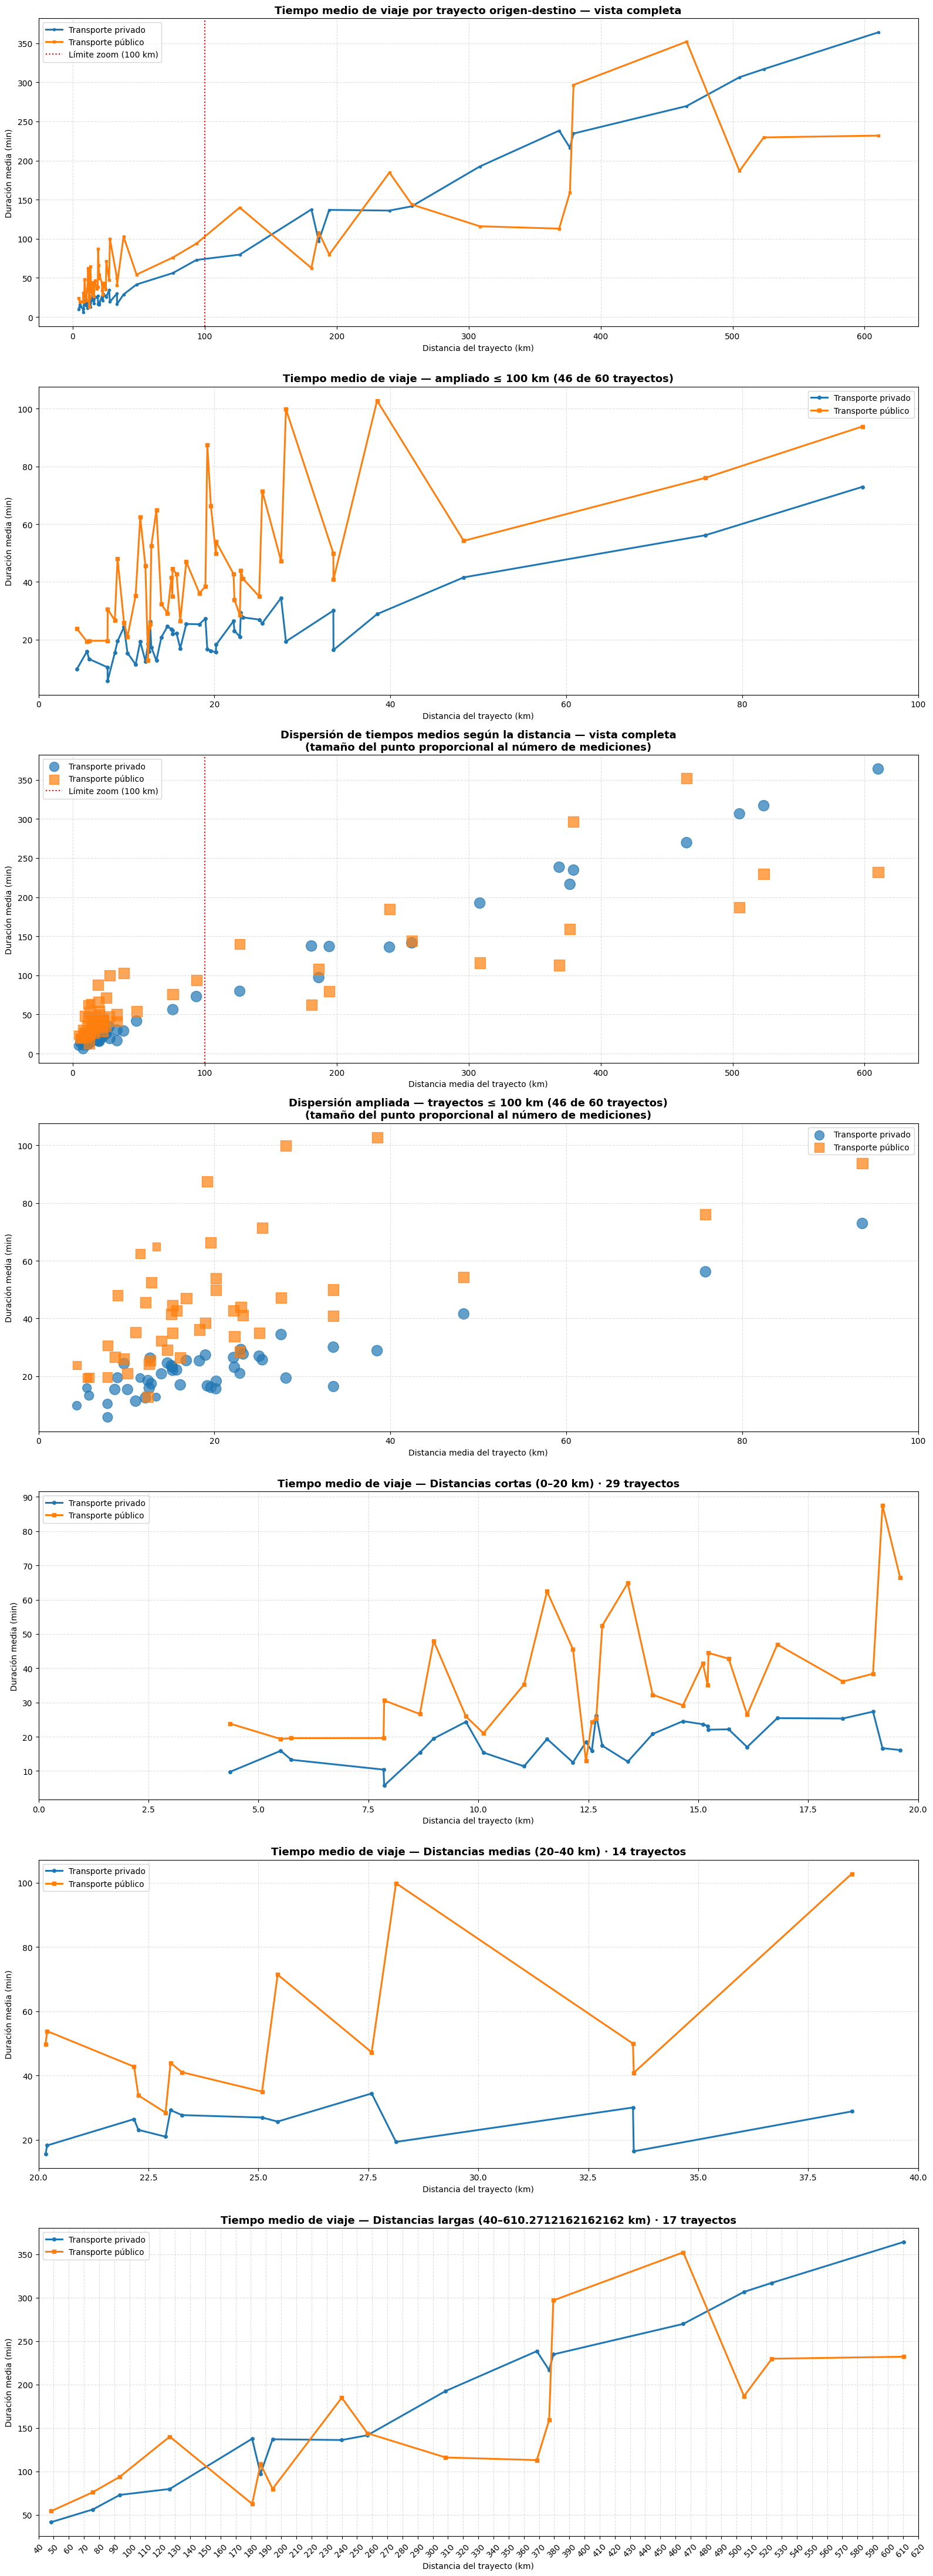


Gráficos guardados como 'comparativa_lineal_y_dispersion.png'
Tabla exportada como 'tabla_comparativa_trayectos.csv'

COEFICIENTE DE DETERMINACIÓN r²
Comparación                                    Ponderado  Sin pond.
----------------------------------------------------------------------
Transporte privado  vs  Transporte público         0.737      0.738
(Ponderado = por número de mediciones de cada trayecto)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. CARGA DE DATOS
# ─────────────────────────────────────────────
df_drive = pd.read_csv('datos_limpios_drive.csv')
df_trans = pd.read_csv('datos_limpios_transportes.csv')

# ─────────────────────────────────────────────
# 2. COLUMNAS IMPORTANTES
# ─────────────────────────────────────────────
COL_ORIGEN      = 'origen'
COL_DESTINO     = 'destino'
COL_DIST        = 'distancia_km'
COL_PRIVADO_CON = 'duracion_con_trafico_min'
COL_PUBLICO     = 'duracion_sin_trafico_min'

# ─────────────────────────────────────────────
# 3. AGRUPAR POR ORIGEN-DESTINO (MEDIA POR TRAYECTO)
# ─────────────────────────────────────────────
drive_agg = (
    df_drive
    .dropna(subset=[COL_DIST, COL_PRIVADO_CON])
    .groupby([COL_ORIGEN, COL_DESTINO], as_index=False)
    .agg(
        distancia_drive  = (COL_DIST,        'mean'),
        tiempo_privado   = (COL_PRIVADO_CON, 'mean'),
        n_drive          = (COL_PRIVADO_CON, 'count')
    )
)

trans_agg = (
    df_trans
    .dropna(subset=[COL_DIST, COL_PUBLICO])
    .groupby([COL_ORIGEN, COL_DESTINO], as_index=False)
    .agg(
        distancia_publico = (COL_DIST,    'mean'),
        tiempo_publico    = (COL_PUBLICO, 'mean'),
        n_publico         = (COL_PUBLICO, 'count')
    )
)

# ─────────────────────────────────────────────
# 4. UNIR SOLO LOS TRAYECTOS COMUNES
# ─────────────────────────────────────────────
df = pd.merge(
    drive_agg,
    trans_agg,
    on=[COL_ORIGEN, COL_DESTINO],
    how='inner'
)

# ─────────────────────────────────────────────
# 5. DISTANCIA MEDIA DEL TRAYECTO
# ─────────────────────────────────────────────
df['distancia_km'] = df[['distancia_drive', 'distancia_publico']].mean(axis=1)

# Peso de cada trayecto: media entre n_drive y n_publico
df['peso'] = (df['n_drive'] + df['n_publico']) / 2

# Etiqueta del trayecto
df['trayecto'] = df[COL_ORIGEN].astype(str) + ' → ' + df[COL_DESTINO].astype(str)

# Ordenar por distancia
df = df.sort_values('distancia_km').reset_index(drop=True)
df['trayecto_id'] = range(1, len(df) + 1)

# ─────────────────────────────────────────────
# 6. RESUMEN GENERAL
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("RESUMEN GENERAL DE TRAYECTOS COMPARABLES")
print("="*80)

print(f"Total de trayectos comparables: {len(df)}\n")

print("Primeros trayectos ordenados por distancia:")
print(df[['trayecto', 'distancia_km',
          'tiempo_privado', 'tiempo_publico',
          'n_drive', 'n_publico', 'peso']].head(20).to_string(index=False))

# ─────────────────────────────────────────────
# 7. GRÁFICOS
# ─────────────────────────────────────────────
ZOOM_KM = 100   # límite del diagrama de dispersión ampliado

# Rangos de distancia para diagramas detallados
RANGOS = [
    (0,  20,  'Distancias cortas'),
    (20, 40,  'Distancias medias'),
    (40, df['distancia_km'].max(), 'Distancias largas'),
]

fig, axes = plt.subplots(7, 1, figsize=(16, 44))

# ─────────────────────────────────────────────
# GRÁFICO 1: DIAGRAMA LINEAL
# ─────────────────────────────────────────────
axes[0].plot(df['distancia_km'], df['tiempo_privado'],
             label='Transporte privado', linewidth=2.2, marker='o', markersize=3)
axes[0].plot(df['distancia_km'], df['tiempo_publico'],
             label='Transporte público', linewidth=2.2, marker='s', markersize=3)

axes[0].set_title('Tiempo medio de viaje por trayecto origen-destino — vista completa', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Distancia del trayecto (km)', fontsize=10)
axes[0].set_ylabel('Duración media (min)', fontsize=10)
axes[0].axvline(x=ZOOM_KM, color='red', linestyle=':', linewidth=1.5, label=f'Límite zoom ({ZOOM_KM} km)')
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

# ─────────────────────────────────────────────
# GRÁFICO 2: DIAGRAMA LINEAL AMPLIADO (zoom)
# ─────────────────────────────────────────────
df_zoom_line = df[df['distancia_km'] <= ZOOM_KM].copy()

axes[1].plot(df_zoom_line['distancia_km'], df_zoom_line['tiempo_privado'],
             label='Transporte privado', linewidth=2.2, marker='o', markersize=4)
axes[1].plot(df_zoom_line['distancia_km'], df_zoom_line['tiempo_publico'],
             label='Transporte público', linewidth=2.2, marker='s', markersize=4)

axes[1].set_title(
    f'Tiempo medio de viaje — ampliado ≤ {ZOOM_KM} km ({len(df_zoom_line)} de {len(df)} trayectos)',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('Distancia del trayecto (km)', fontsize=10)
axes[1].set_ylabel('Duración media (min)', fontsize=10)
axes[1].set_xlim(0, ZOOM_KM)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

# ─────────────────────────────────────────────
# GRÁFICO 3: DIAGRAMA DE DISPERSIÓN COMPLETO
# ─────────────────────────────────────────────
scatter_size = df['peso'] / df['peso'].max() * 150 + 20

axes[2].scatter(df['distancia_km'], df['tiempo_privado'],
                alpha=0.7, s=scatter_size, label='Transporte privado')
axes[2].scatter(df['distancia_km'], df['tiempo_publico'],
                alpha=0.7, s=scatter_size, label='Transporte público', marker='s')

axes[2].axvline(x=ZOOM_KM, color='red', linestyle=':', linewidth=1.5,
                label=f'Límite zoom ({ZOOM_KM} km)')

axes[2].set_title(
    'Dispersión de tiempos medios según la distancia — vista completa\n'
    '(tamaño del punto proporcional al número de mediciones)',
    fontsize=13, fontweight='bold'
)
axes[2].set_xlabel('Distancia media del trayecto (km)', fontsize=10)
axes[2].set_ylabel('Duración media (min)', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.4)
axes[2].legend()

# ─────────────────────────────────────────────
# GRÁFICO 4: DIAGRAMA DE DISPERSIÓN AMPLIADO (zoom)
# ─────────────────────────────────────────────
df_zoom = df[df['distancia_km'] <= ZOOM_KM].copy()
scatter_size_zoom = df_zoom['peso'] / df_zoom['peso'].max() * 150 + 20

axes[3].scatter(df_zoom['distancia_km'], df_zoom['tiempo_privado'],
                alpha=0.7, s=scatter_size_zoom, label='Transporte privado')
axes[3].scatter(df_zoom['distancia_km'], df_zoom['tiempo_publico'],
                alpha=0.7, s=scatter_size_zoom, label='Transporte público', marker='s')

axes[3].set_title(
    f'Dispersión ampliada — trayectos ≤ {ZOOM_KM} km ({len(df_zoom)} de {len(df)} trayectos)\n'
    '(tamaño del punto proporcional al número de mediciones)',
    fontsize=13, fontweight='bold'
)
axes[3].set_xlabel('Distancia media del trayecto (km)', fontsize=10)
axes[3].set_ylabel('Duración media (min)', fontsize=10)
axes[3].set_xlim(0, ZOOM_KM)
axes[3].grid(True, linestyle='--', alpha=0.4)
axes[3].legend()

# ─────────────────────────────────────────────
# GRÁFICOS 5-7: DIAGRAMA LINEAL POR RANGO DE DISTANCIA
# ─────────────────────────────────────────────
for idx, (km_min, km_max, etiqueta) in enumerate(RANGOS, start=4):
    df_rango = df[(df['distancia_km'] > km_min) & (df['distancia_km'] <= km_max)].copy()

    if len(df_rango) == 0:
        axes[idx].set_title(f'{etiqueta} ({km_min}–{km_max} km) — sin datos', fontsize=13)
        continue

    axes[idx].plot(df_rango['distancia_km'], df_rango['tiempo_privado'],
                   label='Transporte privado', linewidth=2.2, marker='o', markersize=4)
    axes[idx].plot(df_rango['distancia_km'], df_rango['tiempo_publico'],
                   label='Transporte público', linewidth=2.2, marker='s', markersize=4)

    axes[idx].set_title(
        f'Tiempo medio de viaje — {etiqueta} ({km_min}–{km_max} km) · {len(df_rango)} trayectos',
        fontsize=13, fontweight='bold'
    )
    axes[idx].set_xlabel('Distancia del trayecto (km)', fontsize=10)
    axes[idx].set_ylabel('Duración media (min)', fontsize=10)
    axes[idx].set_xlim(km_min, km_max)
    if etiqueta == 'Distancias largas':
        axes[idx].set_xticks(np.arange(km_min, km_max + 10, 10))
        axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, linestyle='--', alpha=0.4)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('comparativa_lineal_y_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráficos guardados como 'comparativa_lineal_y_dispersion.png'")

# ─────────────────────────────────────────────
# 8. EXPORTAR TABLA FINAL
# ─────────────────────────────────────────────
df.to_csv('tabla_comparativa_trayectos.csv', index=False)
print("Tabla exportada como 'tabla_comparativa_trayectos.csv'")

# ─────────────────────────────────────────────
# 9. COEFICIENTE DE DETERMINACIÓN r² PONDERADO
# ─────────────────────────────────────────────
weights = df['peso']

def r2_ponderado(x, y, w):
    """Pearson r ponderado al cuadrado entre dos series."""
    x_bar = np.average(x, weights=w)
    y_bar = np.average(y, weights=w)
    num = np.sum(w * (x - x_bar) * (y - y_bar))
    den = np.sqrt(
        np.sum(w * (x - x_bar)**2) *
        np.sum(w * (y - y_bar)**2)
    )
    return (num / den) ** 2

def r2_sin_ponderar(x, y):
    return x.corr(y) ** 2

# ── transporte privado  vs  transporte público ────────────────────────────────
r2_p  = r2_ponderado(df['tiempo_privado'], df['tiempo_publico'], weights)
r2_sp = r2_sin_ponderar(df['tiempo_privado'], df['tiempo_publico'])

print("\n" + "="*70)
print("COEFICIENTE DE DETERMINACIÓN r²")
print("="*70)
print(f"{'Comparación':<45} {'Ponderado':>10} {'Sin pond.':>10}")
print("-"*70)
print(f"{'Transporte privado  vs  Transporte público':<45} {r2_p:>10.3f} {r2_sp:>10.3f}")
print("="*70)
print("(Ponderado = por número de mediciones de cada trayecto)")